# Historical notebook 05 results: 6 October 2026

This is a read-only presentation snapshot of the original fixed-scenario, Halton-weight experiment, including its saved outputs. Use the [active notebook 05](../05_train_multiple_pilots.ipynb) to start a new run. These results do not measure the updated training recipe.

# Original combat reward population: independent JSBSim F-16 pilots

Train any positive number of independent PPO pilots using the same event-based
`CombatReward` formula as [notebook 04](../04_train_rl_pilot.ipynb), with varied relative
reward weights. Defaults: **10 pilots, 150 epochs per pilot, 50 training scenarios**.
Each pilot has its own network, optimizer, reward definition, MLflow run, and checkpoint.
Pilots train sequentially; persistent CPU processes collect their flights concurrently,
and CUDA graphs accelerate PPO updates when a GPU is available.

All pilots face BVR Sim's existing **simple opponent**, using JSBSim flight dynamics.
The transformer, two-second observation history, 33 skills, and PPO algorithm are shared
with the other pilot notebooks. IDs describe experiments, not predetermined behaviours.

Results go into a new timestamped `artifacts/rl_pilot_notebook/combat/` directory and
the `jsbsim-combat-population` MLflow experiment. Existing batches are never overwritten.
The previous hybrid reward experiment is preserved in
[notebook 06](../06_train_multiple_pilots.ipynb).


**Published output snapshot.** The saved tables and figures below show run `20261006T140858_362365Z`: **10 pilots, 150 epochs, 75 training scenarios and 50 validation scenarios**. The executable default above remains 50 training scenarios; this run used `BVR_PILOT_SCENARIOS=75`. Outputs were restored from the [published model manifests and epoch logs](../../shared/models/notebook05-combat-20261006T140858_362365Z/README.md), without rerunning training. The final skill chart uses the saved deterministic replay of pilot 001's first validation scenario, verified against the original replay's checkpoint, seed and return. Figures are embedded PNGs, so viewing this notebook does not require local artifact files or Git LFS downloads. Blank execution counters distinguish these restored outputs from a new notebook run.


## Setup

Install dependencies from the repository root, then restart the kernel:

```bash
python -m pip install -e '.[ml,video]'
```

For GPU training, install a CUDA-enabled PyTorch build in the selected kernel's
environment and restart the kernel. See `docs/multi_pilot_training.md` for setup.
Policy inference and PPO updates use CUDA when available; JSBSim and opponent
control run in separate CPU processes so Python control code can use multiple cores.
Processes are reused across epochs. `BVR_PILOT_DEVICE` can explicitly select a device.
After a code update, restart the kernel and run from the top; confirm the configuration
prints `simulator_executor: process`. The first flight batch includes worker startup.
`BVR_PILOT_EXECUTOR=thread` restores the previous collector for a timing comparison.

For an installation check, set `BVR_PILOT_EPOCHS=1`, `BVR_PILOT_EPISODE_SECONDS=1`,
`BVR_PILOT_SCENARIOS=3`, `BVR_PILOT_EVALUATION_SCENARIOS=3`, and
`BVR_PILOT_UPDATE_EPOCHS=1` before starting Jupyter. Set `BVR_PILOT_COUNT` to any positive
number (default 10), or define an explicit `PILOTS` list below.
To leave capacity for VS Code and other work, `BVR_PILOT_WORKERS` defaults to 80%
of the logical CPU count, rounded down with a minimum of one worker. `BVR_PILOT_TORCH_THREADS`
caps PyTorch CPU operations at up to 8 threads by default. Both are configurable
before setup; explicit environment values override the defaults. These limits
reduce concurrency but do not reserve specific cores or guarantee a CPU percentage.
CUDA graphs accelerate full PPO minibatches by replaying their GPU operations together.
The 50 update passes, batch size of 64, optimizer, rewards, and validation stay the same.
CPU execution and partial minibatches use the ordinary update path. Set
`BVR_PILOT_CUDA_GRAPHS=0` before setup to disable capture for comparisons.
Notebook 04 retains its ordinary update path. Restart the kernel after code changes.

The progress bar identifies flight collection, PPO updates, validation, and replay saving.
CPU load falls during GPU updates. Compare `rollout_seconds`, `update_seconds`, and
`checkpoint_seconds` in the saved metrics. `cuda_graph_updates: 1` confirms graph use;
`simulator_effective_cores` measures CPU use during simulator steps.

In [ ]:
import json
import os
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Leave CPU capacity for the editor and other applications.
DEFAULT_SIMULATOR_WORKERS = max(1, ((os.cpu_count() or 1) * 80) // 100)
TORCH_THREADS = int(os.getenv(
    "BVR_PILOT_TORCH_THREADS", str(min(8, DEFAULT_SIMULATOR_WORKERS))
))
if TORCH_THREADS < 1:
    raise ValueError("BVR_PILOT_TORCH_THREADS must be positive")
torch.set_num_threads(TORCH_THREADS)

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "bvr_behavior_prediction").exists():
    REPO_ROOT = REPO_ROOT.parent
for source_root in (REPO_ROOT, REPO_ROOT / "bvr_sim_source"):
    if str(source_root) not in sys.path:
        sys.path.insert(0, str(source_root))

from bvr_behavior_prediction.rl.bvr_jsbsim_backend import BVRJSBSimBackend
from bvr_behavior_prediction.rl.config import PilotTrainingConfig, RewardWeights
from bvr_behavior_prediction.rl.environment import BluePilotEnvironment
from bvr_behavior_prediction.rl.multi_pilot import PilotSpec, train_pilots, load_trained_pilot
from bvr_behavior_prediction.rl.reward import combat_reward_definition
from bvr_behavior_prediction.rl.reward_population import combat_population_weights
from bvr_behavior_prediction.rl.trainer import PPOTrainer

SEED = int(os.getenv("BVR_PILOT_SEED", "7"))
# Matched initialization and scenarios isolate reward preferences.
SEED_STRIDE = int(os.getenv("BVR_PILOT_SEED_STRIDE", "0"))
evaluation_seed_value = os.getenv("BVR_PILOT_EVALUATION_SEED")
EVALUATION_SEED = int(evaluation_seed_value) if evaluation_seed_value else None
EPOCHS = int(os.getenv("BVR_PILOT_EPOCHS", "150"))
EPISODE_SECONDS = float(os.getenv("BVR_PILOT_EPISODE_SECONDS", "120"))
PILOT_COUNT = int(os.getenv("BVR_PILOT_COUNT", "10"))
if PILOT_COUNT < 1:
    raise ValueError("BVR_PILOT_COUNT must be positive")
BATCH_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR = Path(os.getenv(
    "BVR_PILOT_OUTPUT", REPO_ROOT / "artifacts/rl_pilot_notebook/combat" / BATCH_ID
)).resolve()
DEVICE = os.getenv("BVR_PILOT_DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
print({"device": DEVICE, "pilot_count": PILOT_COUNT, "epochs_per_pilot": EPOCHS,
       "torch_version": torch.__version__, "cuda_available": torch.cuda.is_available(),
       "torch_threads": torch.get_num_threads(), "output": str(OUTPUT_DIR)})

Saved run settings (restored from published metadata):
{
  "pilot_count": 10,
  "epochs_per_pilot": 150,
  "training_scenarios": 75,
  "validation_scenarios": 50,
  "torch_version": "2.14.1+cu130",
  "simulator_workers": 22,
  "simulator_executor": "process",
  "cuda_graph_updates": true,
  "source_run": "artifacts/rl_pilot_notebook/combat/20261006T140858_362365Z"
}


## BVR Sim backend with JSBSim flight dynamics

Each independent pilot controls one F-16 through the complete `SkillManager` catalogue.
The opponent uses BVR Sim's existing simple baseline. The adapter translates tactical
skills into flight controls and records ACMI telemetry. Logs are isolated by pilot.

In [ ]:
BASE_OBSERVATION_SIZE = BVRJSBSimBackend.OBSERVATION_SIZE
ENERGY_FEATURES = 4
OBSERVATION_SIZE = BASE_OBSERVATION_SIZE + ENERGY_FEATURES


def make_environment_factory(run_config):
    def bvr_jsbsim_backend_factory(scenario_dict, recording_path=None):
        return BVRJSBSimBackend(
            scenario_dict,
            recording_path=recording_path,
            log_dir=run_config.output_dir / "simulator_logs",
        )

    def make_environment(scenario, recording_path=None):
        return BluePilotEnvironment(
            bvr_jsbsim_backend_factory,
            scenario,
            planning_horizon_s=run_config.planning_horizon_s,
            episode_duration_s=run_config.episode_duration_s,
            history_duration_s=run_config.history_duration_s,
            sample_interval_s=run_config.sample_interval_s,
            recording_path=recording_path,
        )

    return make_environment

## Configure pilots and original combat-event weights

`CombatReward` retains the original event rules: lock acquisition, every locked launch,
each avoided missile, opponent destruction, crash/shot-down penalties, safe-airborne
reward, and unlocked-launch penalties. There is no added pursuit, threat-exposure,
or missile-support term, and no new first-event-only or four-missile reward cap.
The shared event-detection fixes remain in place.

`combat_population_weights(PILOT_COUNT)` builds any positive number of reward settings:

- Pilot 001 uses **exactly notebook 04's original weights**.
- The other pilots vary five coefficient groups independently: aircraft-loss penalties,
  opponent-destruction reward, missile-evasion reward, lock/locked-launch rewards, and
  the unlocked-launch penalty. Crash/shot-down and lock/launch ratios stay fixed within
  their groups. A deterministic low-discrepancy sequence selects multipliers between
  0.5 and 2 before normalization; it does not monotonically increase all weights.
- Event coefficients are rescaled so their absolute values sum to the original **534**.
  Ground clearance stays at **+0.02 per safe airborne decision**. This keeps coefficient
  scale comparable; event frequency still changes total returns. Final coefficients may
  fall outside 0.5–2 times the original after normalization.
- Extending the population preserves all previously generated weight settings. The
  displayed table and saved manifests contain the actual coefficients, not style labels.

Edit any `REWARD_WEIGHTS` entry with `replace(RewardWeights(), ...)`, or supply your own
`PilotSpec` list. This changes preferences within the original formula. Learned aggression
and other behaviour must be assessed from outcomes and replays.

Matched seeds keep initialization and the training scenarios the same across independent
pilots. Set `BVR_PILOT_SEED_STRIDE=1000` for different seeds. The same 50 training scenarios
are reused each epoch; 50 separate validation scenarios run on the first, every fifth,
and final epoch. Increasing to 150 epochs adds optimization, not new starting conditions.
Use fresh scenarios for final assessment. All selected checkpoints are compared using
the **unmodified original reward weights** under the common `common_combat` benchmark.


In [ ]:
REWARD_WEIGHTS = combat_population_weights(PILOT_COUNT)
# Optional exact override, for example:
# REWARD_WEIGHTS[0] = replace(RewardWeights(), shot_down=-200.0)


def make_reward_definition(pilot_index):
    return combat_reward_definition(
        f"combat_objective_{pilot_index + 1:03d}", weights=REWARD_WEIGHTS[pilot_index],
    )


PILOTS = [
    PilotSpec(
        pilot_id=f"pilot_{index + 1:03d}",
        seed=SEED + SEED_STRIDE * index,
        reward=make_reward_definition(index),
    )
    for index in range(PILOT_COUNT)
]
COMMON_REWARD = combat_reward_definition("common_combat", weights=RewardWeights())
display(pd.DataFrame([
    {"pilot_id": pilot.pilot_id, "seed": pilot.seed,
     **pilot.reward.parameters["weights"]}
    for pilot in PILOTS
]))


,pilot_id,seed,crashed,shot_down,ground_clearance,target_lock_acquired,fired_with_lock,incoming_missile_avoided,opponent_destroyed,fired_without_lock
0,pilot_001,7,-100.000000,-150.000000,0.02,2.000000,8.000000,20.000000,250.000000,-4.000000
1,pilot_002,7,-113.620912,-170.431369,0.02,1.385054,5.540218,14.992369,225.452445,-2.577632
2,pilot_003,7,-72.730338,-109.095507,0.02,1.528438,6.113751,17.908310,323.976826,-2.646830
3,pilot_004,7,-141.336744,-212.005115,0.02,1.810364,7.241454,22.960222,145.728888,-2.917214
4,pilot_005,7,-74.747860,-112.121790,0.02,2.775911,11.103644,38.108272,290.980235,-4.162288
5,pilot_006,7,-91.699347,-137.549020,0.02,2.075638,8.302552,8.150629,283.326788,-2.896025
6,pilot_007,7,-108.218479,-162.327719,0.02,4.222896,16.891582,17.949540,218.907200,-5.482584
7,pilot_008,7,-124.933776,-187.400665,0.02,0.764178,3.056710,13.671424,200.583478,-3.589769
8,pilot_009,7,-48.449209,-72.673813,0.02,1.114252,4.457008,21.577759,380.857389,-4.870569
9,pilot_010,7,-129.373515,-194.060273,0.02,1.813513,7.254053,38.014302,156.108000,-7.376344


In [ ]:
config = PilotTrainingConfig(
    seed=SEED,
    evaluation_seed=EVALUATION_SEED,
    epochs=EPOCHS,
    episode_duration_s=EPISODE_SECONDS,
    planning_horizon_s=1.0,
    history_duration_s=2.0,
    sample_interval_s=0.1,
    transformer_heads=4,
    transformer_layers=2,
    scenarios_per_epoch=int(os.getenv("BVR_PILOT_SCENARIOS", "50")),
    evaluation_scenarios_per_epoch=int(os.getenv("BVR_PILOT_EVALUATION_SCENARIOS", "50")),
    simulator_workers=int(os.getenv("BVR_PILOT_WORKERS", str(DEFAULT_SIMULATOR_WORKERS))),
    simulator_executor=os.getenv("BVR_PILOT_EXECUTOR", "process"),
    hidden_size=64,
    learning_rate=3e-4,
    update_epochs=int(os.getenv("BVR_PILOT_UPDATE_EPOCHS", "50")),
    minibatch_size=64,
    cuda_graph_updates=os.getenv("BVR_PILOT_CUDA_GRAPHS", "1") != "0",
    checkpoint_interval=max(1, EPOCHS // 5),
    diagnostic_interval=1,
    output_dir=OUTPUT_DIR,
    mlflow_experiment="jsbsim-combat-population",
    mlflow_tracking_uri=f"sqlite:///{(REPO_ROOT / 'artifacts/mlflow.db').as_posix()}",
)
# Explicit pilot definitions above override the legacy config.reward field.
print(json.dumps({key: value for key, value in config.as_dict().items()
                  if key != "reward"}, indent=2))

Saved resolved configuration for pilot_001:
{
  "planning_horizon_s": 1.0,
  "episode_duration_s": 120.0,
  "scenarios_per_epoch": 75,
  "evaluation_scenarios_per_epoch": 50,
  "evaluation_interval": 5,
  "simulator_workers": 22,
  "simulator_executor": "process",
  "epochs": 150,
  "simulation_dt_s": 0.1,
  "seed": 7,
  "evaluation_seed": 100082,
  "hidden_size": 64,
  "history_duration_s": 2.0,
  "sample_interval_s": 0.1,
  "transformer_heads": 4,
  "transformer_layers": 2,
  "learning_rate": 0.0003,
  "discount": 0.99,
  "gae_lambda": 0.95,
  "clip_ratio": 0.2,
  "update_epochs": 50,
  "minibatch_size": 64,
  "entropy_coefficient": 0.01,
  "value_coefficient": 0.5,
  "gradient_clip": 0.5,
  "mixed_precision": true,
  "cuda_graph_updates": true,
  "checkpoint_interval": 30,
  "diagnostic_interval": 1,
  "output_dir": "C:\\Users\\jttur\\VSCodeProjects\\Trajectory_Classification\\artifacts\\rl_pilot_notebook\\combat\\20261006T140858_362365Z\\pilot_001",
  "mlflow_experiment": "jsbsim-c

## Train the roster

This cell trains each pilot from scratch and saves its selected `best_model.pt`. The batch
refuses an existing output directory, so rerunning this cell cannot erase a previous result.
Run setup again for a new timestamp, or choose a new `BVR_PILOT_OUTPUT` directory.

Each checkpoint is selected with that pilot's own validation reward. After training, the
selected checkpoint is evaluated once with a **common benchmark reward**. Use
`benchmark_return` and outcome rates for cross-pilot comparisons; `selection_return` uses
different reward scales. More pilots multiply the total training work.

In [ ]:
results = train_pilots(
    pilots=PILOTS,
    config=config,
    env_factory_builder=make_environment_factory,
    observation_size=OBSERVATION_SIZE,
    device=DEVICE,
    benchmark_reward=COMMON_REWARD,
)
summary = pd.DataFrame(results)
display(summary[[
    "pilot_id", "seed", "reward_name", "selection_return", "benchmark_return",
    "survival_rate", "elimination_rate", "checkpoint",
]])
print(f"Batch manifest: {OUTPUT_DIR / 'pilots.json'}")

Completed training results restored from saved manifests.
Batch manifest: artifacts/rl_pilot_notebook/combat/20261006T140858_362365Z/pilots.json


,pilot_id,seed,reward_name,selection_return,benchmark_return,survival_rate,elimination_rate,checkpoint
0,pilot_001,7,combat_objective_001,133.511600,133.5116,0.42,0.66,pilot_001/best_model.pt
1,pilot_002,7,combat_objective_002,41.948154,78.3752,0.40,0.48,pilot_002/best_model.pt
2,pilot_003,7,combat_objective_003,187.477845,138.6724,0.58,0.54,pilot_003/best_model.pt
3,pilot_004,7,combat_objective_004,36.958168,126.3052,0.46,0.58,pilot_004/best_model.pt
4,pilot_005,7,combat_objective_005,271.778482,169.4588,0.46,0.70,pilot_005/best_model.pt
5,pilot_006,7,combat_objective_006,116.542882,101.8860,0.30,0.62,pilot_006/best_model.pt
6,pilot_007,7,combat_objective_007,142.809475,159.4224,0.54,0.66,pilot_007/best_model.pt
7,pilot_008,7,combat_objective_008,72.853536,143.3704,0.56,0.56,pilot_008/best_model.pt
8,pilot_009,7,combat_objective_009,296.239285,163.2636,0.42,0.74,pilot_009/best_model.pt
9,pilot_010,7,combat_objective_010,66.696687,115.5624,0.40,0.60,pilot_010/best_model.pt


In [ ]:
# Select any completed pilot for inspection. This does not rerun training.
SELECTED_PILOT = os.getenv("BVR_PILOT_VIEW", results[0]["pilot_id"])
selected_result = next(result for result in results if result["pilot_id"] == SELECTED_PILOT)
selected_spec = next(pilot for pilot in PILOTS if pilot.pilot_id == SELECTED_PILOT)
RUN_DIR = OUTPUT_DIR / selected_result["output_dir"]
selected_config = replace(
    config, seed=selected_spec.seed,
    evaluation_seed=selected_result["evaluation_seed"], output_dir=RUN_DIR,
)
trainer = PPOTrainer(
    make_environment_factory(selected_config), OBSERVATION_SIZE, selected_config,
    device=DEVICE, reward_definition=selected_spec.reward,
)
trainer.pilot.load_state_dict(load_trained_pilot(RUN_DIR, DEVICE).state_dict())
trained_pilot = trainer.pilot.eval()

FINAL_EVALUATION_DIR = RUN_DIR / "final_evaluation"
FINAL_EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
final_evaluation_rollouts = []
final_evaluation_manifest = []
for index, scenario in enumerate(trainer.evaluation_scenarios):
    episode_seed = selected_config.resolved_evaluation_seed + index
    acmi_path = FINAL_EVALUATION_DIR / f"scenario_{index:03d}_seed_{episode_seed}.txt.acmi"
    rollout, score, final_info = trainer._episode(
        scenario, episode_seed, recording_path=acmi_path, deterministic=True,
    )
    final_evaluation_rollouts.append(rollout)
    final_evaluation_manifest.append({
        "pilot_id": SELECTED_PILOT,
        "checkpoint_sha256": selected_result["checkpoint_sha256"],
        "reward": selected_spec.reward.as_dict(),
        "scenario_index": index, "seed": episode_seed, "score": score,
        "scenario": scenario.as_dict(), "final_info": final_info, "acmi": acmi_path.name,
    })

manifest_path = FINAL_EVALUATION_DIR / "manifest.json"
manifest_path.write_text(json.dumps(final_evaluation_manifest, indent=2, default=str), encoding="utf8")
print(f"Recorded {len(final_evaluation_manifest)} replays for {SELECTED_PILOT}")
print(f"ACMI directory: {FINAL_EVALUATION_DIR}")

Saved replay manifest: 50 flights for pilot_001
ACMI directory: artifacts/rl_pilot_notebook/combat/20261006T140858_362365Z/pilot_001/final_evaluation


## Compare the pilots

Every selected checkpoint is scored with the original `RewardWeights()` on the same
validation scenarios. Compare `benchmark_return` and combat outcomes across pilots;
their own training/selection returns reflect different preferences. The component table
shows which combat events contributed under the common reward.

`opponent_destroyed_rate` includes any opponent death, matching the original reward.
`elimination_rate` separately reports confirmed missile kills. Inspect survival, missile
avoidance, threat exposure, and replays before describing a pilot as more aggressive.
There is no guarantee that distinct coefficients produce distinct behaviours.

The common benchmark in notebook 06 uses a different formula. Evaluate both populations
under the same reward and scenario set before comparing their numeric scores.

Each pilot also has its own training curves. Evaluation occurs on the first, last, and
every fifth epoch; only fresh validation points are plotted. These scenarios select the
checkpoint and are not a held-out test set. Extra epochs can overfit a fixed training set.
The JSONL files and `pilots.json` can be reloaded later without retraining.


In [ ]:
batch_manifest = json.loads((OUTPUT_DIR / "pilots.json").read_text(encoding="utf8"))
completed = [pilot for pilot in batch_manifest["pilots"] if pilot["status"] == "completed"]
summary = pd.DataFrame(completed)
metrics_by_pilot = {
    pilot["pilot_id"]: pd.read_json(
        OUTPUT_DIR / pilot["output_dir"] / "training_metrics.jsonl", lines=True
    )
    for pilot in completed
}
display(summary[["pilot_id", "benchmark_return", "survival_rate", "elimination_rate",
                 "mean_missiles_avoided", "mean_threatened_seconds"]])
display(pd.DataFrame([
    {"pilot_id": pilot["pilot_id"], **pilot["benchmark_component_means"]}
    for pilot in completed
]).set_index("pilot_id"))

,pilot_id,benchmark_return,survival_rate,elimination_rate,mean_missiles_avoided,mean_threatened_seconds
0,pilot_001,133.5116,0.42,0.66,1.66,57.980
1,pilot_002,78.3752,0.40,0.48,1.82,56.794
2,pilot_003,138.6724,0.58,0.54,2.68,63.630
3,pilot_004,126.3052,0.46,0.58,2.14,56.944
4,pilot_005,169.4588,0.46,0.70,2.36,56.678
5,pilot_006,101.8860,0.30,0.62,1.32,48.730
6,pilot_007,159.4224,0.54,0.66,2.44,65.654
7,pilot_008,143.3704,0.56,0.56,2.58,58.484
8,pilot_009,163.2636,0.42,0.74,1.88,55.928
9,pilot_010,115.5624,0.40,0.60,1.96,56.468


,crashed,fired_with_lock,fired_without_lock,ground_clearance,missile_avoided,opponent_destroyed,shot_down,target_locked
pilot_id,,,,,,,,
pilot_001,0.0,18.88,0.0,1.3516,33.2,165.0,-87.0,2.08
pilot_002,0.0,8.80,0.0,1.3352,36.4,120.0,-90.0,1.84
pilot_003,0.0,9.76,0.0,1.5524,53.6,135.0,-63.0,1.76
pilot_004,0.0,16.48,0.0,1.3452,42.8,145.0,-81.0,1.68
pilot_005,0.0,25.28,0.0,1.3388,47.2,175.0,-81.0,1.64
pilot_006,0.0,22.56,0.0,1.1660,26.4,155.0,-105.0,1.76
pilot_007,0.0,11.36,0.0,1.5024,48.8,165.0,-69.0,1.76
pilot_008,0.0,14.40,0.0,1.4904,51.6,140.0,-66.0,1.88
pilot_009,0.0,24.48,0.0,1.3036,37.6,185.0,-87.0,1.88


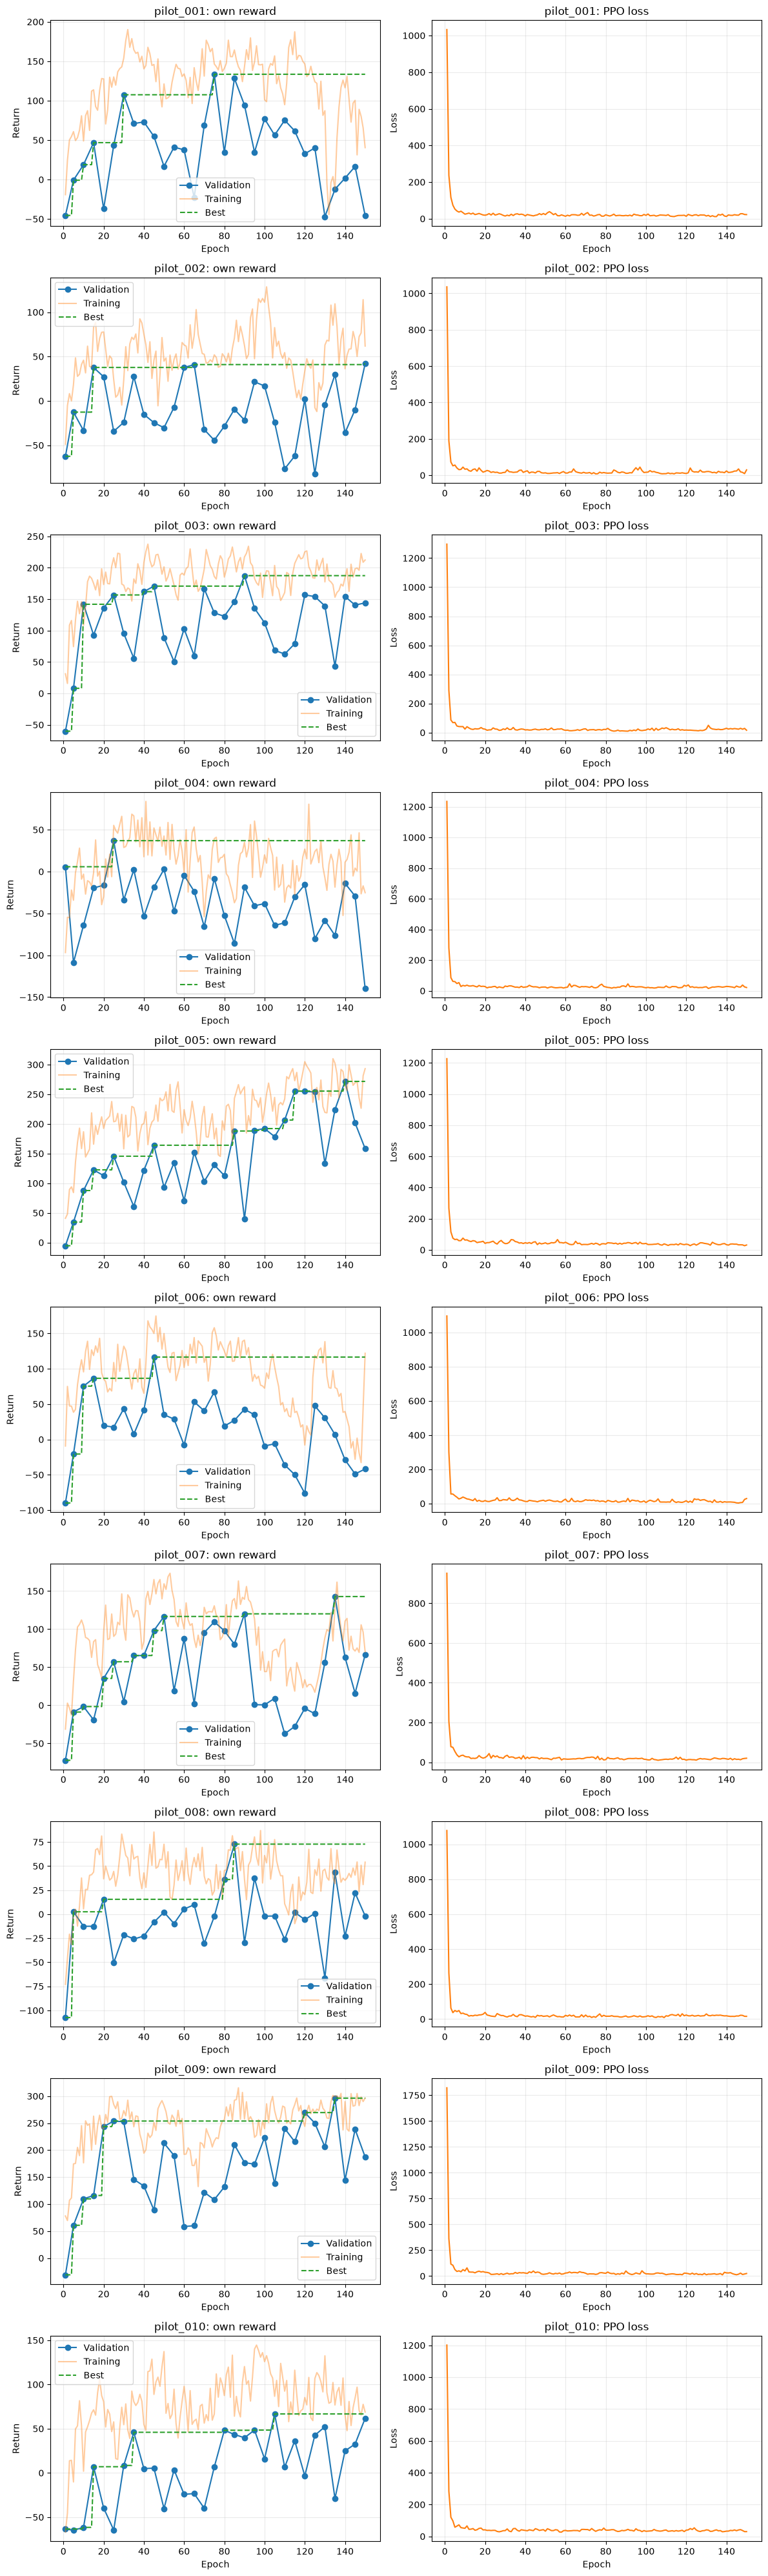

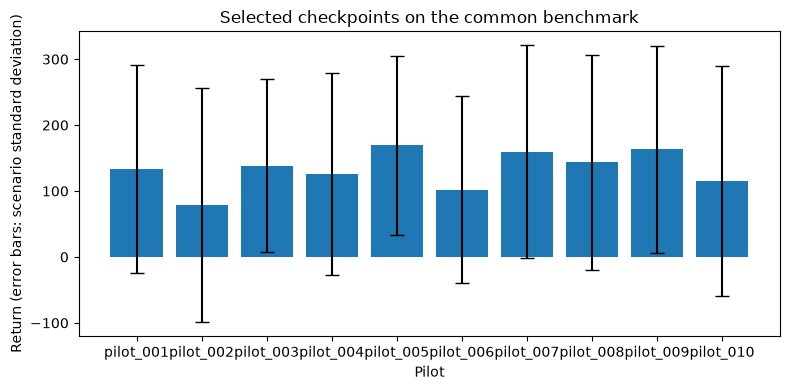

In [ ]:
figure, axes = plt.subplots(len(completed), 2, figsize=(12, 4 * len(completed)), squeeze=False)
for row, pilot in enumerate(completed):
    metrics = metrics_by_pilot[pilot["pilot_id"]]
    evaluated = metrics[metrics["evaluation_performed"] == 1]
    axes[row, 0].plot(evaluated["epoch"], evaluated["mean_return"], marker="o", label="Validation")
    axes[row, 0].plot(metrics["epoch"], metrics["training_mean_return"], alpha=0.4, label="Training")
    axes[row, 0].plot(metrics["epoch"], metrics["best_return"], linestyle="--", label="Best")
    axes[row, 0].set(title=f"{pilot['pilot_id']}: own reward", xlabel="Epoch", ylabel="Return")
    axes[row, 0].legend()
    axes[row, 1].plot(metrics["epoch"], metrics["loss"], color="tab:orange")
    axes[row, 1].set(title=f"{pilot['pilot_id']}: PPO loss", xlabel="Epoch", ylabel="Loss")
    for axis in axes[row]:
        axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

figure, axis = plt.subplots(figsize=(8, 4))
axis.bar(summary["pilot_id"], summary["benchmark_return"],
         yerr=summary["benchmark_return_std"], capsize=5)
axis.set(title="Selected checkpoints on the common benchmark",
         xlabel="Pilot", ylabel="Return (error bars: scenario standard deviation)")
figure.tight_layout()
plt.show()

## Inspect the selected pilot

The replay cell saves the selected pilot's checkpoint hash and reward definition alongside
every ACMI flight. Change `BVR_PILOT_VIEW` or `SELECTED_PILOT` in that cell to inspect
another completed pilot. Open the `.txt.acmi` files in Tacview for the full flights.

Restored skill choices from the saved deterministic replay of pilot_001, validation scenario 1 (seed 100082).
Example ACMI: artifacts\rl_pilot_notebook\combat\20261006T140858_362365Z\pilot_001\final_evaluation\scenario_000_seed_100082.txt.acmi
Evaluation return: 127.38


,decisions
skill,
secondary_shot,21
decelerate_to_speed,21
crank_target_left,17
notch_right,11


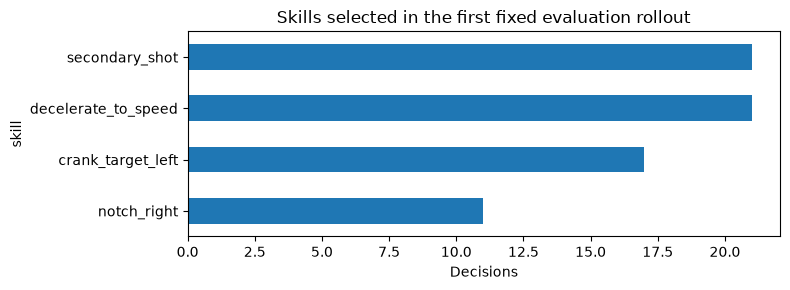

In [ ]:
rollout = final_evaluation_rollouts[0]
first_evaluation = final_evaluation_manifest[0]
evaluation_return = first_evaluation["score"]
final_info = first_evaluation["final_info"]
print(f"Example ACMI: {FINAL_EVALUATION_DIR / first_evaluation['acmi']}")
selected_skills = [trained_pilot.skill_names[index] for index in rollout.skills]
skill_counts = pd.Series(selected_skills).value_counts().rename_axis("skill").rename("decisions")
print(f"Evaluation return: {evaluation_return:.2f}")
display(skill_counts.to_frame())

skill_counts.sort_values().plot.barh(figsize=(8, max(3, len(skill_counts) * 0.35)))
plt.title("Skills selected in the first fixed evaluation rollout")
plt.xlabel("Decisions")
plt.tight_layout()
plt.show()


## Next steps

- Compare the trained pilots in Tacview and on a separate held-out scenario set.
- Tune each `RewardDefinition`, or add more `PilotSpec` entries with unique IDs.
- Use `load_trained_pilot(run_directory)` to load a checkpoint after restarting Python.
- Retain `config.json`, `manifest.json`, and the checkpoint together when publishing through
  `shared/models/`. Each generated flight corpus should identify its pilot and checkpoint hash.
- Checkpoints contain inference weights; they do not resume an interrupted optimizer.